In [1]:
%load_ext autoreload
%autoreload 2
import os
import numpy as np
from IPython.display import display
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torchvision import transforms
from torch.utils.data import DataLoader
import wandb
import h5py

import sys
sys.path.append('../../../src/benchmark/')
sys.path.append('../../../src/utils/')
from build_model import resnet50_
from train_functions import train_epochs, valid
from utils import split_train_valid, list_to_dict, viz_dataloader, hdf5_dataset
from viz import show_images

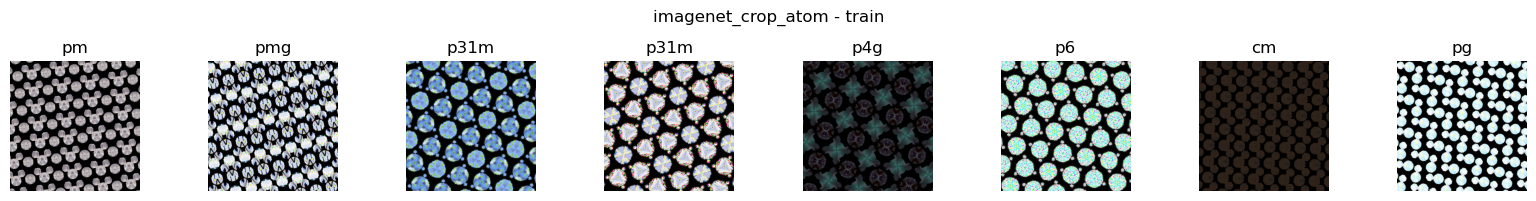

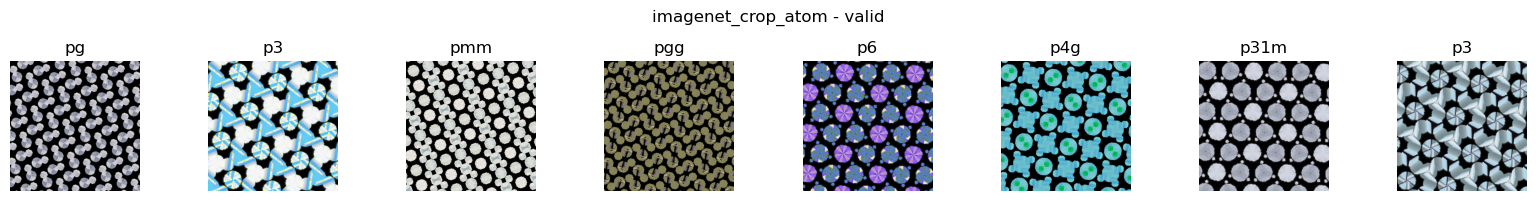

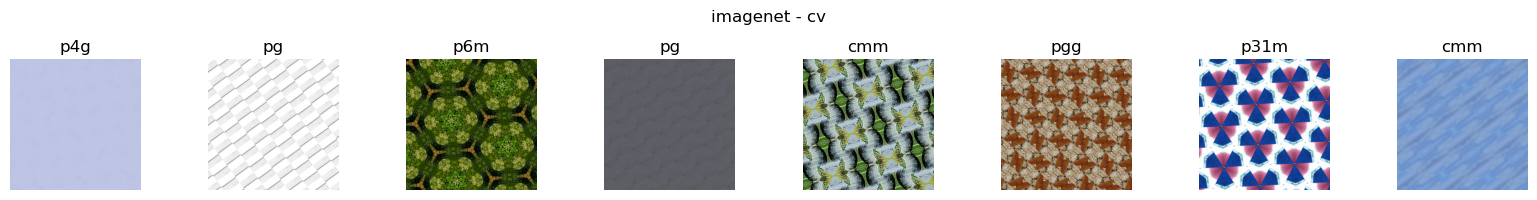

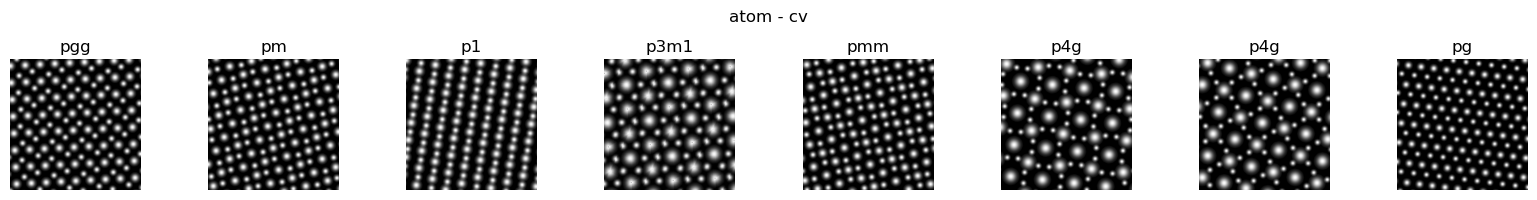

In [2]:
symmetry_classes = ['p1', 'p2', 'pm', 'pg', 'cm', 'pmm', 'pmg', 'pgg', 'cmm', 'p4', 'p4m', 'p4g', 'p3', 'p3m1', 'p31m', 'p6', 'p6m']
label_converter = list_to_dict(symmetry_classes)
bs = 1000

# imagenet_bg_atom
imagenet_bg_atom_ds = hdf5_dataset('../../../../imagenet_crop_atom_v5_1m.h5', folder='imagenet_crop_atom', transform=transforms.ToTensor())
train_ds, valid_ds = split_train_valid(imagenet_bg_atom_ds, 0.8)
train_dl = DataLoader(train_ds, batch_size=bs, shuffle=True, num_workers=3)
viz_dataloader(train_dl, label_converter=label_converter, title='imagenet_crop_atom - train')
valid_dl = DataLoader(valid_ds, batch_size=bs, shuffle=False, num_workers=3)
viz_dataloader(valid_dl, label_converter=label_converter, title='imagenet_crop_atom - valid')

# imagenet_ds
imagenet_ds = hdf5_dataset('../../../../imagenet_v5_rot_10m.h5', folder='train', transform=transforms.ToTensor())
_, imagenet_ds = split_train_valid(imagenet_ds, 0.9)
imagenet_dl = DataLoader(imagenet_ds, batch_size=bs, shuffle=False, num_workers=3)
viz_dataloader(imagenet_dl, label_converter=label_converter, title='imagenet - cv')

# atom
atom_ds = hdf5_dataset('../../../../atom_v5_rot_200k.h5', folder='test', transform=transforms.ToTensor())
atom_dl = DataLoader(atom_ds, batch_size=bs, shuffle=False, num_workers=3)
viz_dataloader(atom_dl, label_converter=label_converter, title='atom - cv')

In [3]:
config = {
    'loss_func': 'CrossEntropyLoss', # nn.MSELoss()
    'optimizer': 'Adam',
    'scheduler': 'OneCycleLR',
}

NAME = '06212024-benchmark-resnet50_from_scratch-imagenet_crop_atom_v5_1m'

# train

In [5]:
wandb.login()
proj_name = 'Understanding-Experimental-Images-by-Identifying-Symmetries-with-Deep-Learning'
wandb.init(project=proj_name, entity='yig319', name=NAME, id=NAME, save_code=True, config=config)
config = wandb.config

wandb: WARNING Calling wandb.login() after wandb.init() has no effect.


In [6]:
model = resnet50_(in_channels=3, n_classes=17)
outputs = model(torch.randn(2,3,256,256))
print(outputs.shape)
model = torch.nn.DataParallel(model, device_ids=[4,5,6])
# model

torch.Size([2, 17])


In [7]:
device = torch.device('cuda:4')
lr = 1e-3
start = 0
epochs = 20

loss_func = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, epochs=epochs, max_lr=lr, steps_per_epoch=len(train_dl))
history = train_epochs(model, loss_func, optimizer, device, train_dl, valid_dl_list=[valid_dl, imagenet_dl, atom_dl], 
                       valid_name_list=['validation', 'imagenet_cv', 'atom_cv'], epochs=epochs, start=start, scheduler=scheduler,
                       valid_every_epochs=5, model_dir='../../../saved_models/06132024-benchmark-ResNet50-imagenet_crop_atom_v5_1m/', tracking=True)

Epoch: 1/20


  0%|          | 0/816 [00:00<?, ?it/s]

100%|██████████| 816/816 [14:43<00:00,  1.08s/it]


Training: Loss: 2.2682, Accuracy: 23.8808%.
Epoch: 2/20


100%|██████████| 816/816 [14:38<00:00,  1.08s/it]


...

validation: Loss: 0.0095, Accuracy: 99.7647%.


100%|██████████| 1072/1072 [16:18<00:00,  1.10it/s]


imagenet_cv: Loss: 6.4619, Accuracy: 24.8811%.


100%|██████████| 204/204 [02:56<00:00,  1.16it/s]


atom_cv: Loss: 0.0241, Accuracy: 99.1191%.
